# STFT and MDCT: same signal, different representations

This example compares the **short-time Fourier transform (STFT)** with the **modified discrete cosine transform (MDCT)**. Run the cells from top to bottom. The default signal is generated here, so no audio file is required.

Requirements: Python 3 with NumPy, SciPy, Matplotlib and IPython (available in most scientific Jupyter environments).

By the end, you should be able to explain:
1. Why STFT coefficients are complex, whereas MDCT coefficients are signed real numbers.
2. Why overlapping MDCT blocks can reconstruct a signal even though each block has fewer coefficients than input samples.
3. Why an MDCT is useful in audio coding, but is **not itself compression**.

We use the **same window length, window shape and hop** for both transforms. This isolates the difference between their representations. STFT here means a windowed, overlapping real-input DFT; MDCT means a lapped cosine transform with time-domain alias cancellation.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, irfft, rfftfreq
from scipy.io import wavfile
from scipy.signal import chirp
from IPython.display import Audio, display, Markdown

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': False})
np.set_printoptions(precision=4, suppress=True)

## 1. Start with a signal we can recognize

The default example contains a low tone throughout, a second tone whose frequency changes twice, a short upward chirp, and a brief transient. These give us recognizable features in time and frequency.

To use a recording instead, set `AUDIO_PATH` below to a WAV file. Stereo is averaged to mono; integer PCM is converted to floating point. `MAX_SECONDS` limits the duration for this teaching implementation.

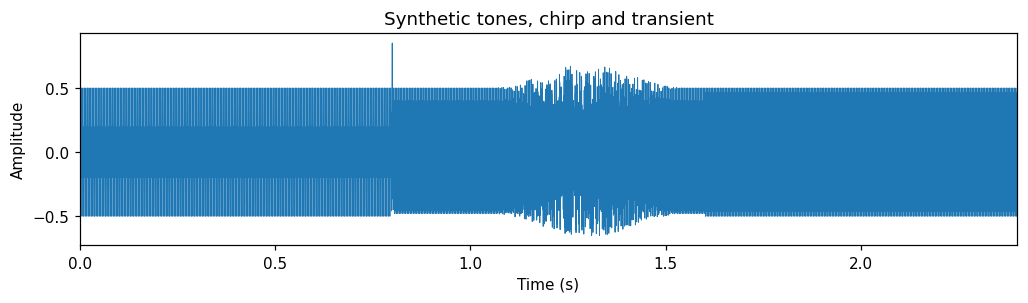

16,000 samples/s; 38,400 samples; 2.40 seconds


In [2]:
AUDIO_PATH = None  # Example: Path('../sounds/487465-trumpet.wav')
MAX_SECONDS = 2.4

def load_wav_mono(path):
    fs, raw = wavfile.read(path)
    if np.issubdtype(raw.dtype, np.unsignedinteger):
        midpoint = (np.iinfo(raw.dtype).max + 1) / 2
        samples = (raw.astype(float) - midpoint) / midpoint
    elif np.issubdtype(raw.dtype, np.signedinteger):
        samples = raw.astype(float) / (2 ** (np.iinfo(raw.dtype).bits - 1))
    elif np.issubdtype(raw.dtype, np.floating):
        samples = raw.astype(float)
    else:
        raise ValueError('Use an integer-PCM or floating-point WAV file.')
    if samples.ndim == 2:
        samples = samples.mean(axis=1)
    if samples.ndim != 1 or samples.size == 0 or not np.all(np.isfinite(samples)):
        raise ValueError('Audio must contain finite, non-empty samples.')
    return int(fs), samples

if AUDIO_PATH is None:
    fs = 16000
    t = np.arange(round(MAX_SECONDS * fs)) / fs
    moving_frequency = np.where(t < 0.8, 750, np.where(t < 1.6, 1500, 2250))
    moving_phase = 2 * np.pi * np.cumsum(moving_frequency) / fs
    x = 0.22 * np.cos(2 * np.pi * 250 * t) + 0.28 * np.cos(moving_phase)
    chirp_mask = (t >= 1.05) & (t < 1.55)
    chirp_time = t[chirp_mask] - 1.05
    x[chirp_mask] += 0.18 * np.sin(np.pi * chirp_time / 0.5) ** 2 * chirp(
        chirp_time, f0=500, f1=3000, t1=0.5)
    x += 0.35 * np.exp(-0.5 * ((t - 0.8) / 0.001) ** 2)
    signal_name = 'Synthetic tones, chirp and transient'
else:
    fs, x = load_wav_mono(AUDIO_PATH)
    x = x[:max(1, round(MAX_SECONDS * fs))]
    t = np.arange(x.size) / fs
    signal_name = Path(AUDIO_PATH).name

# Use one shared playback gain later, keeping all comparisons at the same level.
playback_gain = min(1.0, 0.95 / max(np.max(np.abs(x)), 1e-15))
fig, ax = plt.subplots(figsize=(11, 2.5))
ax.plot(t, x, lw=0.6)
ax.set(xlabel='Time (s)', ylabel='Amplitude', title=signal_name)
ax.set_xlim(0, x.size / fs)
plt.show()
print(f'{fs:,} samples/s; {x.size:,} samples; {x.size/fs:.2f} seconds')

## 2. Match the analysis settings

Let $N$ be the **hop size and number of MDCT coefficients**. Both transforms look at $2N$ samples per block and advance by $N$ samples: **50% overlap**.

We use a sine window, $w[n]=\sin\left[\pi(n+1/2)/(2N)\right]$. Its two overlapping halves satisfy
$$w[n]^2+w[n+N]^2=1,\qquad 0\leq n<N.$$
This is the **Princen–Bradley condition** used here for MDCT reconstruction. Windowing and overlap are necessary, but the MDCT's particular cosine basis also matters.

For block $m$, the MDCT coefficient is
$$C_m[k]=\sqrt{\frac{2}{N}}\sum_{n=0}^{2N-1}x_m[n]w[n]
\cos\left[\frac{\pi}{N}\left(n+\frac12+\frac N2\right)\left(k+\frac12\right)\right],
\quad 0\leq k<N.$$
Here **$C_m[k]$ is the coefficient**: a signed weight on one cosine basis function. This notebook uses a symmetric normalization for the forward and inverse transforms.

The functions below are stateless: rerunning them does not retain samples from a previous signal. Padding covers the first and last samples, and reconstruction is cropped back to the original length. The direct MDCT matrix is easy to inspect; production codecs use faster DCT-IV/FFT-based implementations.

In [3]:
N = 256                      # Try 128 or 512, then rerun from this cell onward.
BLOCK = 2 * N
HOP = N
window = np.sin(np.pi * (np.arange(BLOCK) + 0.5) / BLOCK)
assert np.allclose(window[:N]**2 + window[N:]**2, 1)

n = np.arange(BLOCK)[None, :]
k = np.arange(N)[:, None]
mdct_basis = np.sqrt(2 / N) * np.cos(np.pi / N * (n + 0.5 + N / 2) * (k + 0.5))

def make_frames(samples):
    # Add a full hop at each end, plus enough zeros to complete the final hop.
    right_padding = HOP + (-samples.size) % HOP
    padded = np.pad(samples, (HOP, right_padding))
    frames = np.lib.stride_tricks.sliding_window_view(padded, BLOCK)[::HOP].copy()
    starts = np.arange(frames.shape[0]) * HOP
    return padded, frames, starts

def overlap_add(blocks, starts, padded_length):
    result = np.zeros(padded_length)
    for start, block in zip(starts, blocks):
        result[start:start + BLOCK] += block
    return result

def analyze(samples):
    padded, frames, starts = make_frames(samples)
    stft = rfft(frames * window, axis=1, norm='ortho')
    mdct = (frames * window) @ mdct_basis.T
    return padded, frames, starts, stft, mdct

def synthesize(stft, mdct, starts, padded_length, original_length):
    stft_blocks = irfft(stft, n=BLOCK, axis=1, norm='ortho') * window
    stft_sum = overlap_add(stft_blocks, starts, padded_length)
    weights = overlap_add(np.broadcast_to(window**2, stft_blocks.shape), starts, padded_length)
    stft_padded = np.divide(stft_sum, weights, out=np.zeros_like(stft_sum), where=weights > 1e-14)

    mdct_blocks = (mdct @ mdct_basis) * window
    mdct_padded = overlap_add(mdct_blocks, starts, padded_length)
    crop = slice(HOP, HOP + original_length)
    return stft_padded[crop], mdct_padded[crop], mdct_blocks

padded, frames, starts, S, C = analyze(x)
x_stft, x_mdct, mdct_blocks = synthesize(S, C, starts, padded.size, x.size)
frame_times = (starts - HOP + BLOCK / 2) / fs
stft_frequencies = rfftfreq(BLOCK, 1 / fs)
mdct_frequencies = (np.arange(N) + 0.5) * fs / BLOCK
print(f'Window: {BLOCK} samples ({1000*BLOCK/fs:.1f} ms)')
print(f'Hop: {HOP} samples ({1000*HOP/fs:.1f} ms); overlap: 50%')
print(f'Frequency spacing: {fs/BLOCK:.2f} Hz; blocks: {frames.shape[0]}')

Window: 512 samples (32.0 ms)
Hop: 256 samples (16.0 ms); overlap: 50%
Frequency spacing: 31.25 Hz; blocks: 151


### What is stored in each block?

| With the same $2N$-sample window and $N$-sample hop | STFT | MDCT |
|---|---|---|
| Stored coefficients | $N+1$ unique real-input DFT bins | $N$ cosine coefficients |
| Coefficient type | Complex; DC and Nyquist are real | Signed real |
| Independent real numbers per block | $2N$ | $N$ |
| Frequency centers | $k f_s/(2N)$, including DC and Nyquist | $(k+1/2)f_s/(2N)$ |
| Reconstruction | Inverse DFT, window, weighted overlap-add | Inverse MDCT, window, overlap-add with alias cancellation |
| Long-stream coefficient density | 2 real numbers per new sample | 1 real number per new sample |

The counts use conjugate symmetry of a real-input DFT; they are **not a file-size or bitrate measurement**. MDCT is *critically sampled*: apart from boundary overhead, it stores as many real coefficients as new input samples. A single MDCT block cannot recover its $2N$ inputs independently; its neighbors supply the missing information during reconstruction.

## 3. Compare time–frequency pictures

Look for the steady 250 Hz line, the stepped tone, the rising chirp, and the transient near 0.8 s. Both transforms track the same events.

The color shows magnitude in dB **relative to each transform's own peak**, with the same −80 to 0 dB range. Compare the location and timing of features. Brightness is not a calibrated amplitude comparison: STFT magnitude and absolute MDCT weight measure different projections. Taking absolute values also hides the MDCT coefficient signs, just as STFT magnitude hides complex phase.

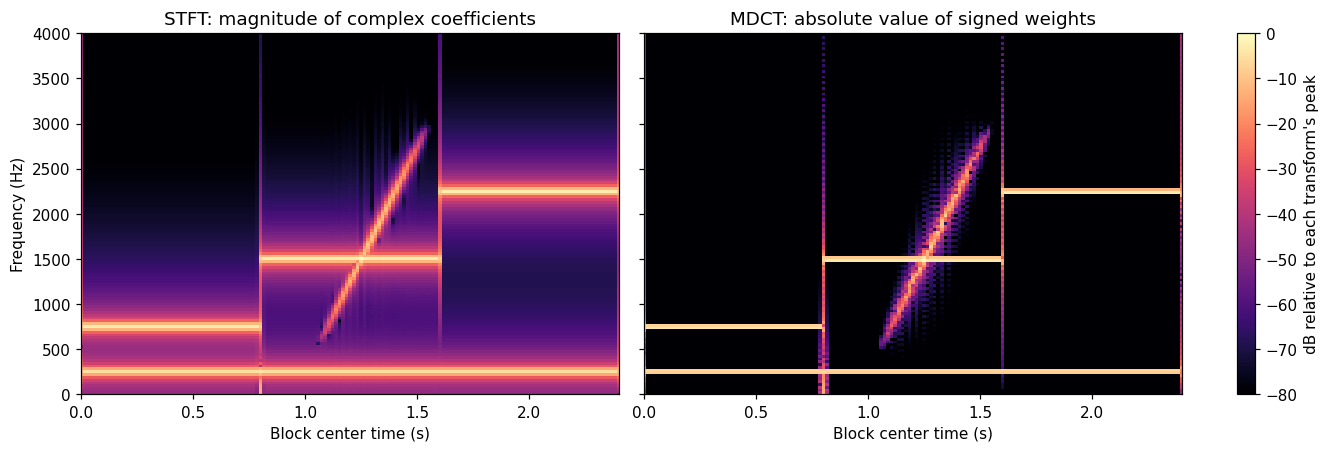

In [4]:
def relative_db(coefficients, floor_db=-80):
    magnitude = np.abs(coefficients)
    peak = max(magnitude.max(), np.finfo(float).tiny)
    return 20 * np.log10(np.maximum(magnitude / peak, 10**(floor_db / 20)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True, layout='constrained')
for ax, coefficients, frequencies, title in zip(
        axes, [S, C], [stft_frequencies, mdct_frequencies],
        ['STFT: magnitude of complex coefficients', 'MDCT: absolute value of signed weights']):
    mesh = ax.pcolormesh(frame_times, frequencies, relative_db(coefficients).T,
                         shading='nearest', cmap='magma', vmin=-80, vmax=0, rasterized=True)
    ax.set(title=title, xlabel='Block center time (s)', xlim=(0, x.size / fs),
           ylim=(0, min(4000, fs / 2)))
axes[0].set_ylabel('Frequency (Hz)')
fig.colorbar(mesh, ax=axes, label="dB relative to each transform's peak")
plt.show()

## 4. Does a real-valued MDCT lose phase?

**No: phase information is encoded differently.** An STFT bin has a complex magnitude and angle. An MDCT coefficient has a real value whose sign indicates the direction of its projection onto a fixed cosine basis. Negative means subtract that basis function; it does not mean “negative frequency.”

A sign alone can only flip a basis function by $\pi$; it cannot specify an arbitrary phase angle. The phase of the original waveform is carried **collectively by the pattern of weights across frequency and neighboring overlapping blocks**. A single MDCT bin has no separate phase parameter.

Below, two tones have the same amplitude and frequency but different phases. Their STFT magnitudes are very similar, while their complex angles differ. Their MDCT weights also change. This comparison uses the same finite window for both tones.

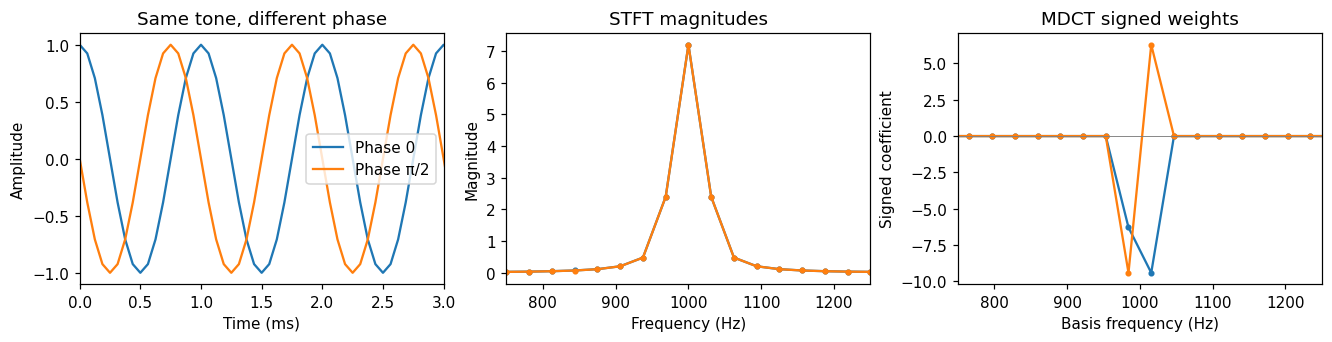

Phase 0: STFT angle at 1000.0 Hz = -0.000 rad
Phase π/2: STFT angle at 1000.0 Hz = 1.571 rad


In [5]:
phase_t = np.arange(BLOCK) / fs
tone_frequency = fs / 16  # 1000 Hz at the default sample rate; below Nyquist for any fs.
phases = [0.0, np.pi / 2]
tones = np.array([np.cos(2 * np.pi * tone_frequency * phase_t + phase) for phase in phases])
tone_stft = rfft(tones * window, axis=1, norm='ortho')
tone_mdct = (tones * window) @ mdct_basis.T
labels = ['Phase 0', 'Phase π/2']
fig, axes = plt.subplots(1, 3, figsize=(12, 3), layout='constrained')
for row, label in enumerate(labels):
    axes[0].plot(1000 * phase_t, tones[row], label=label)
    axes[1].plot(stft_frequencies, np.abs(tone_stft[row]), '.-', label=label)
    axes[2].plot(mdct_frequencies, tone_mdct[row], '.-', label=label)
axes[0].set(title='Same tone, different phase', xlabel='Time (ms)', ylabel='Amplitude', xlim=(0, 3000/tone_frequency))
axes[1].set(title='STFT magnitudes', xlabel='Frequency (Hz)', ylabel='Magnitude', xlim=(0.75*tone_frequency, 1.25*tone_frequency))
axes[2].set(title='MDCT signed weights', xlabel='Basis frequency (Hz)', ylabel='Signed coefficient', xlim=(0.75*tone_frequency, 1.25*tone_frequency))
axes[2].axhline(0, color='gray', lw=0.6)
axes[0].legend()
plt.show()
nearest_bin = np.argmin(abs(stft_frequencies - tone_frequency))
for row, label in enumerate(labels):
    print(f'{label}: STFT angle at {stft_frequencies[nearest_bin]:.1f} Hz = '
          f'{np.angle(tone_stft[row, nearest_bin]):.3f} rad')

## 5. Reconstruct and check the samples

Neither transform should lose information here: we keep every coefficient and use the matching inverse. The error should be close to floating-point precision. Padding is removed before comparison, so the lengths and alignment match exactly.

The STFT inverse divides the sum of overlapping windowed blocks by the sum of squared windows. The MDCT inverse relies on the compatible window and basis to cancel aliasing. It must not be treated as a collection of independent inverse DCT blocks.

| Transform | Maximum absolute error | RMSE | SNR (dB) |
|---|---:|---:|---:|
| STFT | 3.89e-16 | 6.69e-17 | 311.6 |
| MDCT | 6.56e-14 | 1.63e-14 | 263.9 |

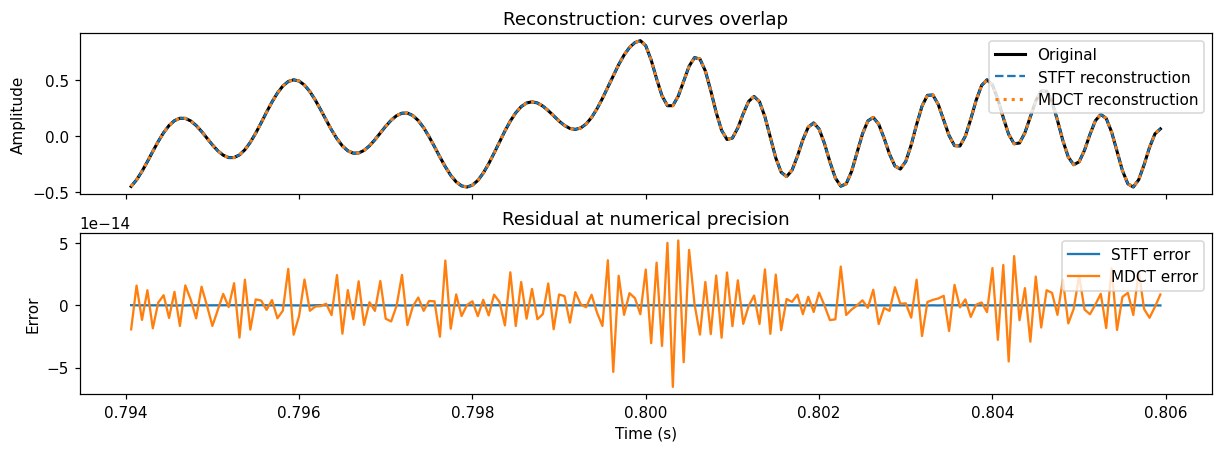

In [6]:
def error_metrics(reference, reconstructed):
    error = reconstructed - reference
    rmse = np.sqrt(np.mean(error**2))
    signal_rms = np.sqrt(np.mean(reference**2))
    snr = (np.inf if rmse == 0 else
           20 * np.log10(signal_rms / rmse) if signal_rms > 0 else -np.inf)
    return np.max(np.abs(error)), rmse, snr

rows = []
for name, reconstructed in [('STFT', x_stft), ('MDCT', x_mdct)]:
    assert reconstructed.shape == x.shape
    max_error, rmse, snr = error_metrics(x, reconstructed)
    assert np.allclose(reconstructed, x, atol=1e-10, rtol=1e-10), f'{name} reconstruction failed'
    rows.append(f'| {name} | {max_error:.2e} | {rmse:.2e} | {snr:.1f} |')
display(Markdown('| Transform | Maximum absolute error | RMSE | SNR (dB) |\n'
                 '|---|---:|---:|---:|\n' + '\n'.join(rows)))

zoom_center = min(0.8, x.size / (2 * fs))
zoom = abs(t - zoom_center) < 0.006
fig, axes = plt.subplots(2, 1, figsize=(11, 4), sharex=True, layout='constrained')
axes[0].plot(t[zoom], x[zoom], color='black', lw=2, label='Original')
axes[0].plot(t[zoom], x_stft[zoom], '--', label='STFT reconstruction')
axes[0].plot(t[zoom], x_mdct[zoom], ':', lw=2, label='MDCT reconstruction')
axes[0].set(ylabel='Amplitude', title='Reconstruction: curves overlap')
axes[0].legend(loc='upper right')
axes[1].plot(t[zoom], (x_stft-x)[zoom], label='STFT error')
axes[1].plot(t[zoom], (x_mdct-x)[zoom], label='MDCT error')
axes[1].set(xlabel='Time (s)', ylabel='Error', title='Residual at numerical precision')
axes[1].legend(loc='upper right')
plt.show()

In [7]:
# Optional listening: one shared gain, with automatic normalization disabled.
for label, samples in [('Original', x), ('STFT reconstruction', x_stft), ('MDCT reconstruction', x_mdct)]:
    display(Markdown(f'**{label}**'))
    display(Audio(samples * playback_gain, rate=fs, normalize=False))

**Original**

**STFT reconstruction**

**MDCT reconstruction**

## 6. See “lapped” reconstruction and alias cancellation

**Lapped** means adjacent transform blocks overlap and are designed to reconstruct together. MDCT maps $2N$ windowed samples to $N$ weights, so its inverse for one block contains an alias component. Here *alias* means mixing/folding within the transform; it is not the aliasing caused by sampling an analog signal too slowly.

In the overlap region, compare each inverse block with the contribution we would like it to provide: the original samples multiplied by that half-window squared. The two differences are equal and opposite. Adding the neighboring blocks cancels them, and the window-square condition makes the desired contributions sum to the original signal. This is **time-domain alias cancellation (TDAC)**.

The plots below show actual inverse-block contributions before the final overlap-add. Removing overlap or using an incompatible window would break this result.

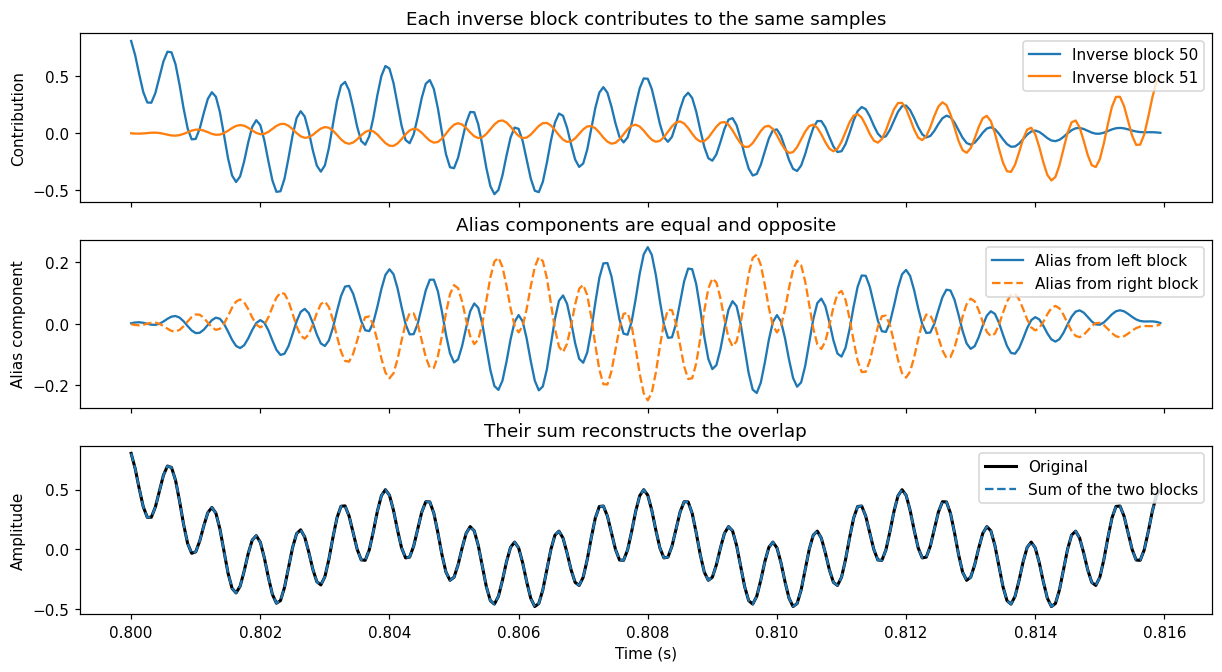

Maximum error in this overlap: 6.56e-14


In [8]:
# Choose an interior overlap near the transient (or the middle of a short recording).
j = int(np.clip(round(zoom_center * fs / HOP), 0, len(frames) - 2))
overlap_start = starts[j] + HOP
original_overlap = padded[overlap_start:overlap_start + HOP]
left_contribution = mdct_blocks[j, HOP:]
right_contribution = mdct_blocks[j + 1, :HOP]
left_alias = left_contribution - original_overlap * window[HOP:]**2
right_alias = right_contribution - original_overlap * window[:HOP]**2
overlap_times = (overlap_start - HOP + np.arange(HOP)) / fs

assert np.allclose(left_alias + right_alias, 0, atol=1e-10, rtol=0)
fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True, layout='constrained')
axes[0].plot(overlap_times, left_contribution, label=f'Inverse block {j}')
axes[0].plot(overlap_times, right_contribution, label=f'Inverse block {j+1}')
axes[0].set(title='Each inverse block contributes to the same samples', ylabel='Contribution')
axes[1].plot(overlap_times, left_alias, label='Alias from left block')
axes[1].plot(overlap_times, right_alias, '--', label='Alias from right block')
axes[1].set(title='Alias components are equal and opposite', ylabel='Alias component')
axes[2].plot(overlap_times, original_overlap, color='black', lw=2, label='Original')
axes[2].plot(overlap_times, left_contribution + right_contribution, '--', label='Sum of the two blocks')
axes[2].set(title='Their sum reconstructs the overlap', xlabel='Time (s)', ylabel='Amplitude')
for ax in axes:
    ax.legend(loc='upper right')
plt.show()
print(f'Maximum error in this overlap: {np.max(abs(left_contribution + right_contribution - original_overlap)):.2e}')

## Takeaways and experiments

- **STFT:** overlapping DFT blocks provide complex coefficients with explicit per-bin magnitude and phase. With these settings, the representation is redundant.
- **MDCT:** overlapping cosine blocks provide signed real weights at critical sampling. Phase is encoded collectively; TDAC makes the complete representation invertible.
- **Same time–frequency tradeoff:** a longer window gives finer frequency spacing and spreads brief events over a longer time. Matching the settings makes this visible in both transforms. The MDCT frequency grid is shifted by half a bin.
- **Why codecs use MDCT:** critical sampling avoids the coefficient redundancy of this overlapping STFT; windowed blocks reduce block-boundary artifacts; quantizing and entropy-coding the real weights can give efficient compression. Perceptual bit allocation is an additional codec step. The transform alone does not reduce file size or guarantee better quality.
- **Check samples, not just pictures or playback:** the numerical reconstruction and TDAC checks confirm that boundary handling, scaling and alignment are correct.

Try changing `N` to 128 or 512 and rerun from section 2 onward. Compare how the transient and chirp change. Then try your WAV recording. To explore compression, deliberately quantize coefficients before inversion; a fair codec comparison must also control bitrate, quantization and perceptual quality.

### References

- [SciPy: STFT and overlap-add reconstruction](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.stft.html).
- [SciPy: real-input FFT and Hermitian symmetry](https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.rfft.html).
- [Shao & Johnson: DCT-IV and MDCT algorithms](https://arxiv.org/html/0708.4399v2).
- [Vorbis I specification: inverse MDCT, windowing and overlap-add](https://xiph.org/vorbis/doc/Vorbis_I_spec.html).